<a href="https://colab.research.google.com/github/asmitaagarwal756/Earthquake-Prediction/blob/main/Linear%2C_logistics%2C_polynomial_Earthquake_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mean Squared Error (MSE): 0.1607
Root Mean Squared Error (RMSE): 0.4009
Mean Absolute Error (MAE): 0.3220
R² Score: 0.8817


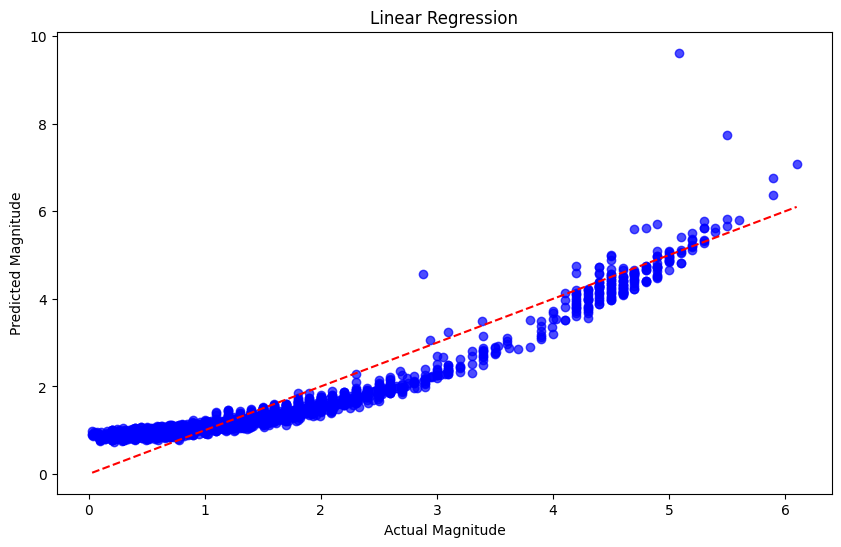

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("earthquakes.csv")

drop_cols = [
    'time.hour','time.minute','time.month','time.second',
    'time.year','time.day','time.epoch','time.full','location.name'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(["impact.magnitude"], axis=1)
y = df["impact.magnitude"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Plot Predicted vs Actual Magnitude
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.show()

Mean Squared Error (MSE): 0.0743
Root Mean Squared Error (RMSE): 0.2726
Mean Absolute Error (MAE): 0.1777
R² Score: 0.9453


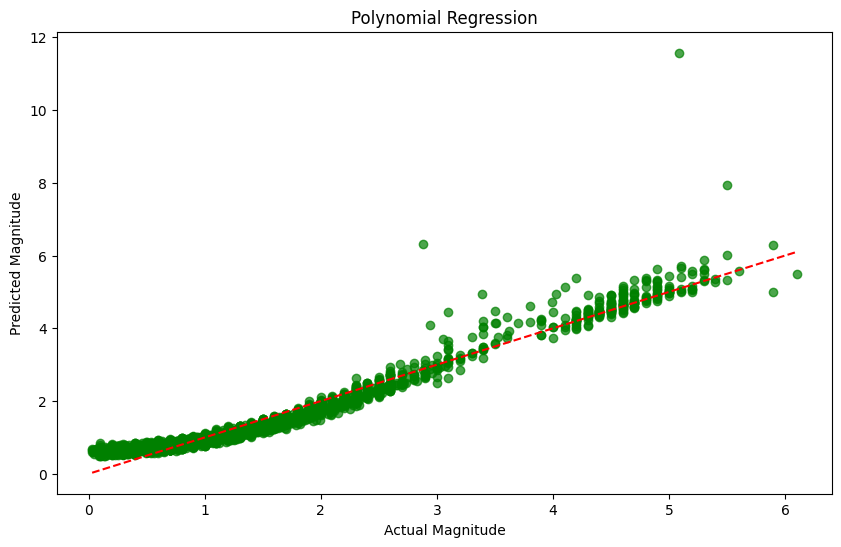

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv("earthquakes.csv")

drop_cols = [
    'time.hour','time.minute','time.month','time.second',
    'time.year','time.day','time.epoch','time.full','location.name'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])


for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(["impact.magnitude"], axis=1)
y = df["impact.magnitude"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

poly = PolynomialFeatures(degree=2)   #can adjust degree (e.g., 2, 3, etc.)
X_poly = poly.fit_transform(X_scaled)


X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.3, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

#Plot Predicted vs Actual Magnitude
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Polynomial Regression")
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.show()

Accuracy: 0.9976
Sensitivity (Recall): 0.8780
Specificity: 0.9996
Precision: 0.9730
F1 Score: 0.9231
ROC-AUC Score: 0.9997


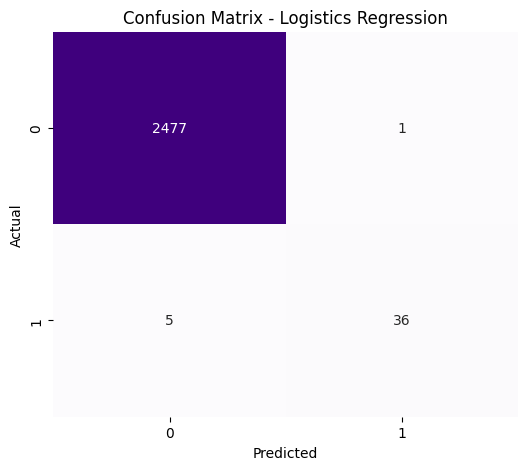

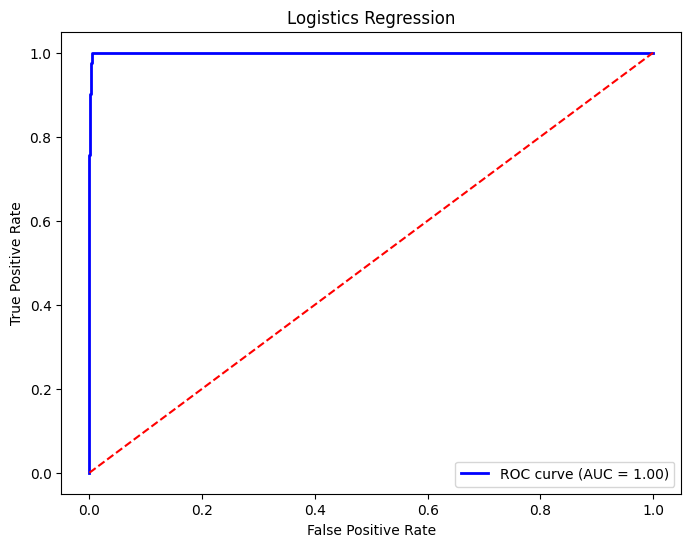

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

df = pd.read_csv("earthquakes.csv")

drop_cols = [
    'time.hour','time.minute','time.month','time.second',
    'time.year','time.day','time.epoch','time.full','location.name'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

df["StrongQuake"] = (df["impact.magnitude"] >= 5.0).astype(int)

X = df.drop(["impact.magnitude","StrongQuake"], axis=1)
y = df["StrongQuake"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)


y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:,1]


accuracy = accuracy_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)  # Recall
specificity = recall_score(y_test, y_pred, pos_label=0)  # True Negative Rate
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy: {accuracy:.4f}")
print(f"Sensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False)
plt.title("Confusion Matrix - Logistics Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.title("Logistics Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

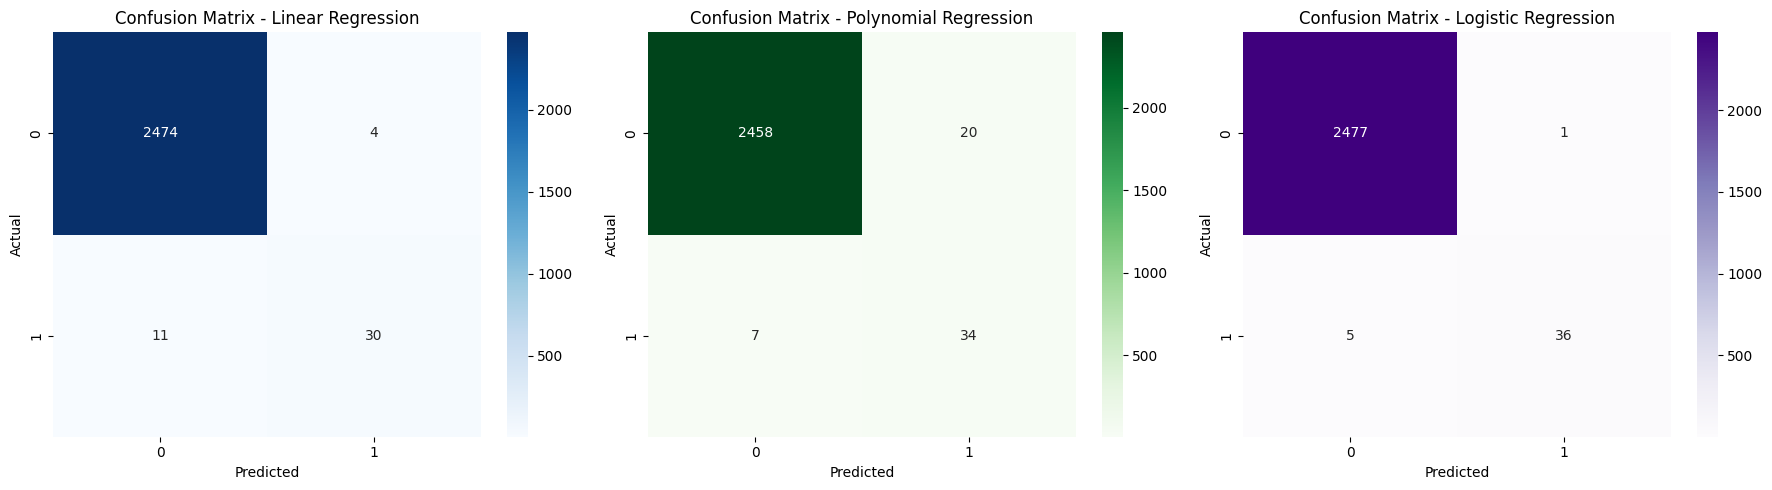

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix

df = pd.read_csv("earthquakes.csv")

drop_cols = [
    'time.hour','time.minute','time.month','time.second',
    'time.year','time.day','time.epoch','time.full','location.name'
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))


X = df.drop(["impact.magnitude"], axis=1)
y = df["impact.magnitude"]

y_binary = (y >= 5.0).astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)
y_train_binary = (y_train >= 5.0).astype(int)
y_test_binary = (y_test >= 5.0).astype(int)

# ---------------- Linear Regression ----------------
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
y_pred_lin_binary = (y_pred_lin >= 5.0).astype(int)
cm_lin = confusion_matrix(y_test_binary, y_pred_lin_binary)

# ---------------- Polynomial Regression ----------------
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)
y_pred_poly_binary = (y_pred_poly >= 5.0).astype(int)
cm_poly = confusion_matrix(y_test_binary, y_pred_poly_binary)

# ---------------- Logistic Regression ----------------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train_binary)
y_pred_log = log_reg.predict(X_test)
cm_log = confusion_matrix(y_test_binary, y_pred_log)

# ---------------- Visualization ----------------
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.heatmap(cm_lin, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Linear Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_poly, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Confusion Matrix - Polynomial Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(cm_log, annot=True, fmt="d", cmap="Purples", ax=axes[2])
axes[2].set_title("Confusion Matrix - Logistic Regression")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()